In [1]:
#Function 6
#You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. 
#Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, 
#where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
#To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, 
#to maximise the negative of the total sum.


In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from scipy.interpolate import griddata

# 1. Load 5D spatial coordinate data and output values
inputs = np.load('/home/mcevoyj777/_CAPSTONE/FUNC6/initial_inputs.npy')
output = np.load('/home/mcevoyj777/_CAPSTONE/FUNC6/initial_outputs.npy')
print(output.max())
extra_inputs = [[0.424516, 0.367334, 0.467170, 0.746827, 0.158948],[0.188862, 0.514438, 0.083176, 0.938769, 0.000001],
                [0.892895, 0.772634, 0.937451, 0.406290, 0.360158],[0.427487, 0.295840, 0.570672, 0.780035, 0.190551],
               [0.370791, 0.175107, 0.656395, 0.940692, 0.236384],[0.479940, 0.323820, 0.646369, 0.734312, 0.264380],
               [0.332131, 0.283475, 0.973347, 0.723901, 0.193395],[0.000000, 0.317806, 0.626706, 0.907558, 0.167783]]
extra_output = [-0.33663026414694064,-1.2679820129946602,-1.7016255198269483,
                -0.16260391178773215,-0.5210499647366378,-0.27987100150491395,
               -0.6279802117175647,-0.6535354094291767]

inputs = np.vstack([inputs, extra_inputs])
output = np.append(output, extra_output)
print(output.max())
np.set_printoptions(precision=9, suppress=True)
print(inputs)
print(output)

# 2. Combine into a single Pandas DataFrame
df = pd.DataFrame(inputs, columns=['Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'])
df['Output_Target'] = output

# 3. Compute the correlation matrix
# Change method to 'spearman' if relationships ar8e non-linear curves
corr_matrix = df.corr(method='pearson')

# 4. Isolate how each input correlates *only* with the target output
target_corr = corr_matrix['Output_Target'].drop('Output_Target')

print("Correlation with Output:")
print(target_corr)

# Calculate non-linear relationship dependency (higher score = stronger relationship)
mi_scores = mutual_info_regression(inputs, output)

for name, score in zip(['Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'], mi_scores):
    print(f"{name} Mutual Information Score: {score:.4f}")

# Fit a quick non-linear model that checks all 4 dimensions simultaneously
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(inputs, output)

# Extract total feature importances (including interactions)
importances = model.feature_importances_

for name, score in zip(['Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'], importances):
    print(f"{name} Total Importance (with interactions): {score:.4f}")

-0.7142649478202404
-0.16260391178773215
[[0.728186105 0.15469257  0.732551669 0.693996509 0.056401311]
 [0.242384347 0.844099972 0.577809099 0.679021284 0.501952888]
 [0.72952261  0.7481062   0.679774641 0.356552279 0.671053683]
 [0.770620242 0.114403744 0.046779932 0.648324285 0.273549053]
 [0.618812299 0.331802137 0.187287868 0.756238474 0.328834798]
 [0.784958094 0.910682349 0.708120104 0.959225429 0.004911496]
 [0.145110786 0.896684598 0.896322235 0.726271537 0.236271991]
 [0.945069068 0.288459051 0.978805764 0.961655587 0.598015936]
 [0.125720155 0.862724692 0.028544332 0.246605272 0.751206241]
 [0.757594355 0.355831415 0.0165229   0.434207205 0.112433044]
 [0.536796903 0.308780907 0.411879285 0.388225177 0.522528304]
 [0.957739669 0.235668572 0.09914585  0.156805934 0.071317373]
 [0.629307895 0.803483678 0.811408439 0.045613186 0.110624462]
 [0.021735308 0.42808424  0.835939437 0.489488659 0.511081735]
 [0.439344264 0.698923833 0.426820222 0.109476085 0.877888468]
 [0.258905574 

In [6]:
import numpy as n767
from sklearn.ensemble import RandomForestRegressor

# Train a predictive model on your 20 existing samples
predictor = RandomForestRegressor(n_estimators=100, random_state=42)
predictor.fit(inputs, output)

def objective_5d(X):
    """
    Surrogate function for 5D optimization.
    X: A 2D numpy array of shape (n_samples, 5) sent by the optimizer.
    """
    # Force input to be 2D array matrix for sklearn compatibility
    X = np.atleast_2d(X)
    
    # Predict the output value using the trained model
    predictions = predictor.predict(X)
    
    # Return as a flat 1D array as expected by your code (.ravel())
    return predictions.ravel()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def upper_confidence_bound(mu, sigma, kappa=0.1):
    """
    Upper Confidence Bound (UCB) acquisition function.
    
    UCB = mean + kappa * std
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation
    kappa : exploration parameter (higher = more exploration)
    """
    return mu + kappa * sigma


def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    Expected Improvement (EI) acquisition function.
    
    EI = E[max(f(x) - f(x_best), 0)]
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation  
    y_best : best observed value so far
    xi : exploration parameter
    """
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [13]:
def bayesian_optimization_nd(objective_func, n_dims, n_iterations=1, 
                            n_initial=1, acquisition='ei'):
    """
    Bayesian Optimization for n-dimensional functions.
    Assumes bounds [0, 1] for all dimensions.
    """
    bounds = [(0, 1) for _ in range(n_dims)]
    
    # Initialize
    X_samples = inputs
    y_samples = output

    #Define initial length scales based on your feature importance.
    # Lower value = High sensitivity/importance (Model pays close attention to tiny movements)
    # Higher value = Low sensitivity/passenger (Model assumes changes have very little local impact)
    initial_length_scales = np.array([
        0.5,  # Input_V (Moderate interaction)
        0.2,  # Input_W (High negative correlation)
        1.0,  # Input_X (The passenger - highly smoothed out)
        0.05,  # Input_Y (The major driver - hyper-sensitive tracking)
        0.1   # Input_Z (Strongest penalty trap)
    ])
    length_scale_bounds = [(1e-2, 1e2) for _ in range(n_dims)]
    
    best_values = [y_samples.max()]
    
    print(f"Starting {n_dims}D optimization with {n_initial} initial samples...")
    print(f"Initial best: {y_samples.max():.4f}\n")
  
    
    for iteration in range(n_iterations):
        # Fit GP
        ard_kernel = C(1.0, (1e-3, 1e3)) * Matern(
            length_scale=initial_length_scales, 
            length_scale_bounds=length_scale_bounds, 
            nu=2.5  # nu=2.5 enforces Matérn 5/2 behavior
            )
        gp = GaussianProcessRegressor(kernel=ard_kernel, alpha=1e-6,normalize_y=True,
                                     n_restarts_optimizer=10)
        gp.fit(X_samples, y_samples)

        # Optimize acquisition function
        def acq_objective(X):
            X = X.reshape(1, -1)
            mu, sigma = gp.predict(X, return_std=True)
            
            if acquisition == 'ei':
                acq_val = expected_improvement(mu, sigma, y_samples.max())
            else:
                acq_val = upper_confidence_bound(mu, sigma, kappa=0.5)
           
            return -acq_val
        
        # Multi-start optimization
        best_acq = np.inf
        X_next = None
        
        for _ in range(150):  # More starts for higher dimensions
            x0 = np.random.uniform(0, 1, n_dims)
            result = minimize(acq_objective, x0, bounds=bounds, method='L-BFGS-B')
            if result.fun < best_acq:
                best_acq = result.fun
                X_next = result.x
                print(f"Optimized Next Point Found! Predicted Acquisition Score: {-best_acq:.6f}")
                print(f"Coordinates to test next: {X_next}")

       
        # Evaluate
        y_next = objective_func(X_next.reshape(1, -1)).ravel()
        
        # Update
        X_samples = np.vstack([X_samples, X_next])
        y_samples = np.append(y_samples, y_next)
        best_values.append(y_samples.max())
        
        if (iteration + 1) % 10 == 0:
            print(f"Iteration {iteration + 1}: Best f(x)={y_samples.max():.4f}")
    
        return X_samples, y_samples, best_values



# Run 6D optimization
X_samples_5d, y_samples_5d, best_values_5d = bayesian_optimization_nd(
    objective_5d, 
    n_dims=5,
    n_iterations=15,
    acquisition=''
)

Starting 5D optimization with 1 initial samples...
Initial best: -0.1626

Optimized Next Point Found! Predicted Acquisition Score: -0.040892
Coordinates to test next: [0.419948225 0.285695187 0.615926247 0.791801747 0.         ]
Optimized Next Point Found! Predicted Acquisition Score: -0.040892
Coordinates to test next: [0.41994864  0.285695375 0.615926293 0.79180196  0.         ]
Optimized Next Point Found! Predicted Acquisition Score: -0.040892
Coordinates to test next: [0.419948673 0.285695259 0.615925921 0.791802044 0.         ]
Optimized Next Point Found! Predicted Acquisition Score: -0.040892
Coordinates to test next: [0.419948631 0.28569528  0.615925889 0.79180198  0.         ]
Optimized Next Point Found! Predicted Acquisition Score: -0.040892
Coordinates to test next: [0.419948667 0.285695279 0.615925906 0.791801984 0.         ]
Optimized Next Point Found! Predicted Acquisition Score: -0.040892
Coordinates to test next: [0.419948658 0.285695296 0.615925869 0.791802029 0.       

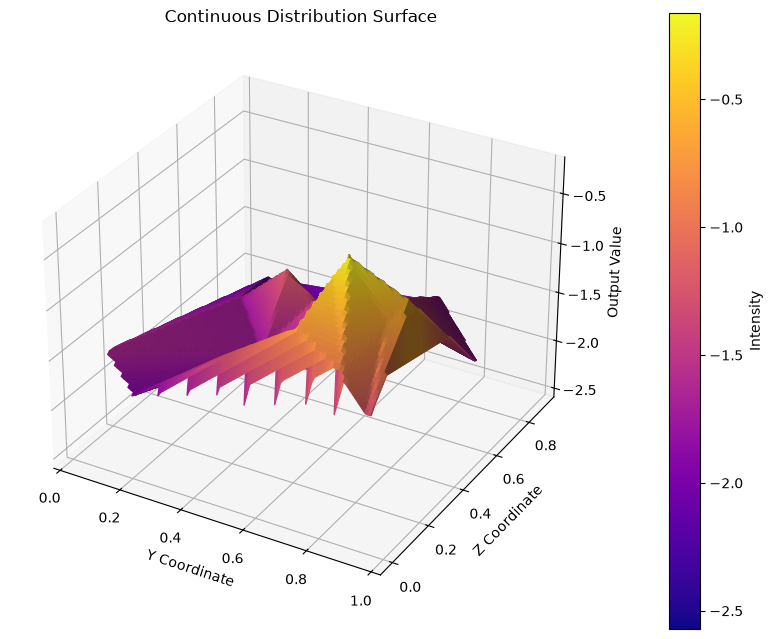

In [14]:

coords = (inputs[:,3],inputs[:,4])

# 1. Define a regular 2D grid based on your data boundaries
grid_x, grid_y = np.meshgrid(
    np.linspace(coords[0].min(), coords[0].max(), 100),
    np.linspace(coords[1].min(), coords[1].max(), 100)
)

# 2. Interpolate the scattered (x, y, z) data onto the uniform grid
# Options for method: 'linear', 'cubic', or 'nearest'
grid_z = griddata((coords[0], coords[1]), output, (grid_x, grid_y), method='linear')

# If your y_clean variable is different from values, interpolate it too for the colors
grid_color = griddata((coords[0], coords[1]), output, (grid_x, grid_y), method='linear')

# 3. Create the 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

norm = colors.Normalize(vmin=output.min(), vmax=output.max())

# Plot the continuous surface
# facecolors overrides standard mapping to use your output
surf = ax.plot_surface(
    grid_x, grid_y, grid_z,
    facecolors=plt.cm.plasma(norm(grid_color)),
    rcount=100, ccount=100,  # Grid resolution
    antialiased=True,
    shade=True
)

# 4. Design elements
# Create a dummy scalar mappable object just to display the colorbar correctly
mappable = plt.cm.ScalarMappable(cmap='plasma', norm = colors.Normalize(vmin=output.min(), vmax=output.max()))
fig.colorbar(mappable, ax=ax, label="Intensity", pad=0.1)

ax.set_xlabel("Y Coordinate")
ax.set_ylabel("Z Coordinate")
ax.set_zlabel("Output Value")

ax.set_title("Continuous Distribution Surface")

plt.show()


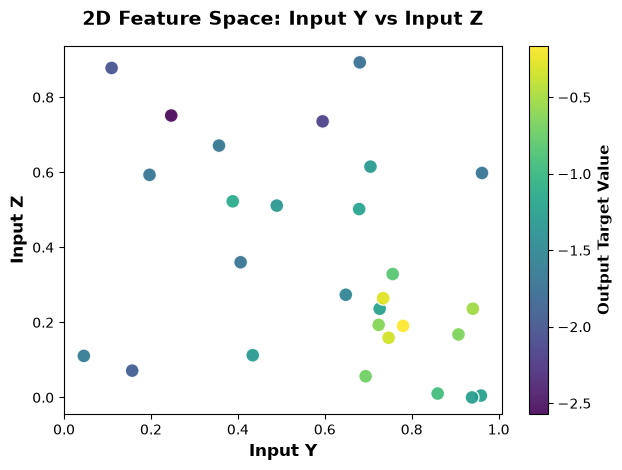

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Create scatter plot with a continuous color mapping (viridis)
scatter = plt.scatter(
    data=df, 
    x='Input_Y', 
    y='Input_Z', 
    c='Output_Target', 
    cmap='viridis', 
    s=100,            # Marker size
    edgecolor='w',    # White border around markers
    alpha=0.9
)

# Add elements
cbar = plt.colorbar(scatter)
cbar.set_label('Output Target Value', fontsize=11, fontweight='bold')
plt.xlabel('Input Y', fontsize=12, fontweight='bold')
plt.ylabel('Input Z', fontsize=12, fontweight='bold')
plt.title('2D Feature Space: Input Y vs Input Z', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()